In [1]:
import numpy as np
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys
import os

sys.path.append(os.path.abspath('../scripts'))
import ocean_analysis as oa 

Vortex box saving is DEACTIVATED.


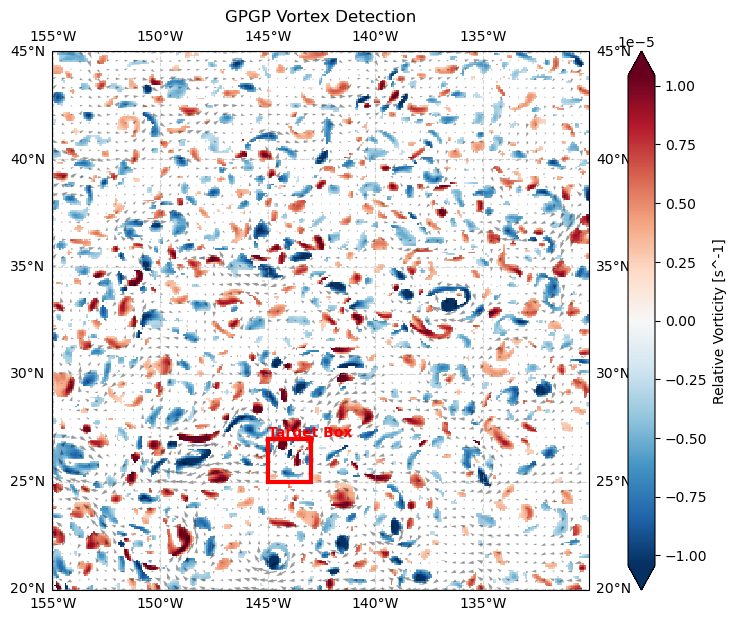

Stats for red box:
Number of eddy core pixels: 196


In [ ]:
# 1. Load Data
surface_ds = oa.process_glorys_data('../data/GPGP_oct2020.nc', averaging_period='1D')

# 2. Compute Metrics
results = oa.calculate_okubo_weiss(surface_ds)
signed_vort, ro_intensity, mask = oa.get_eddy_intensity(results, alpha=0.2)
    
# 3. SELECT TARGET DOMAIN
# lat_s, lat_n = 25.0, 27.0
# lon_w, lon_e = -145.0, -143.0
# lat_s, lat_n = 22.5, 27.5
# lon_w, lon_e = -145.0, -140.0
lat_s, lat_n = 20.0, 45.0
lon_w, lon_e = -155.0, -130.0


les_box = oa.get_subdomain(lat_min=lat_s, lon_min=lon_w, lat_max=lat_n, lon_max=lon_e)
oa.preprocess_netcdf('../data/GPGP_oct2020.nc', les_box, active=False)

# 4. Visualize with the Red Rectangle
oa.plot_eddy_intensity(signed_vort, u=surface_ds.uo, v=surface_ds.vo, 
                       title="GPGP Vortex Detection",
                       target_box=les_box)

# 5. Extract statistics strictly inside that box
box_data = signed_vort.sel(longitude=slice(les_box[0], les_box[1]), 
                           latitude=slice(les_box[2], les_box[3]))

print(f"Stats for red box:")
print(f"Number of eddy core pixels: {int(box_data.notnull().sum())}")

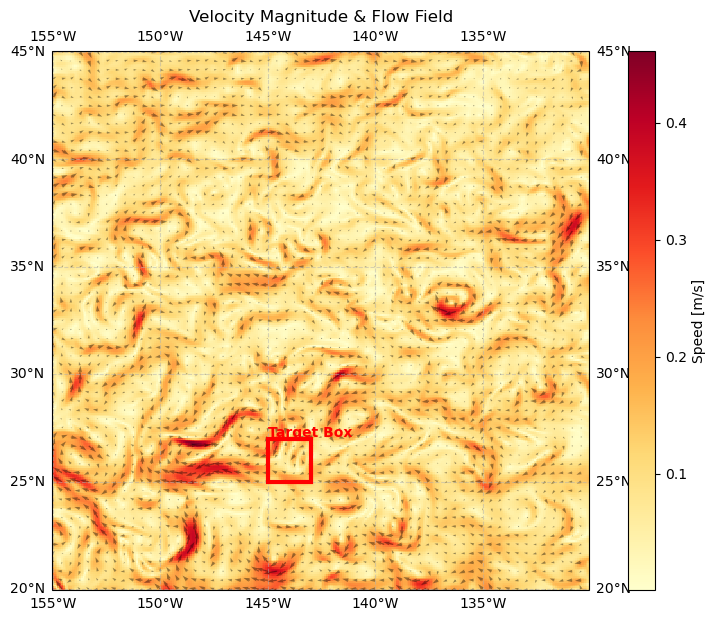

In [3]:
# 6. Plot Velocity Field
oa.plot_ocean_field(
    np.sqrt(surface_ds.uo**2 + surface_ds.vo**2),
    u=surface_ds.uo, v=surface_ds.vo,
    title="Velocity Magnitude & Flow Field",
    cmap='YlOrRd',
    label="Speed [m/s]",
    target_box=les_box,
    vector_scale=15
)